# Очистка чертежа: классификация штрихов и поиск наконечников

| шаг | что делает | результат |
|---|---|---|
| 1 | загрузка, единый масштаб | `img_bgr` |
| 2 | детекция текста (PP-OCRv5 det) | `text_region` |
| 3 | бинаризация | `strokes` |
| 4 | граф скелета, толщина ребра, доля текста | `graph` |
| 5 | склейка ребер в цепи | `chains` |
| 6 | классы толщины, KMeans без текста | `classes` |
| 7 | перерисовка сохраненных линий | `clean_mask` |

Текст ищется не ради текста, а чтобы буквы не смещали распределение толщин, по которому KMeans
ставит границы классов. Поэтому граф строится до кластеризации: чистить выборку надо целыми
ребрами, а не пикселями внутри прямоугольника.

Соглашения кода:
- данные шага живут в неизменяемом датаклассе, а не в словаре и не в DataFrame;
- DataFrame используется только внутри `report_*` для печати;
- `run_*` ничего не вычисляет, только вызывает чистые функции, отчет и отрисовку;
- параметры подбираются слайдерами, результат лежит в `ui_*.result`.

## 0. Импорты и типы

In [277]:
from dataclasses import dataclass
from itertools import combinations
from pathlib import Path

import cv2
import numpy as np
import numpy.typing as npt
import pandas as pd
from ipywidgets import Checkbox, Dropdown, FloatSlider, IntSlider, interactive
from matplotlib import pyplot as plt
from matplotlib.axes import Axes
from matplotlib.collections import LineCollection
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from scipy.spatial import cKDTree
from skan import Skeleton, summarize
from skimage.morphology import skeletonize
from sklearn.cluster import KMeans

Img = npt.NDArray[np.uint8]  # BGR или одноканальная картинка
Mask = npt.NDArray[np.bool_]
Floats = npt.NDArray[np.float64]
Ints = npt.NDArray[np.int64]
Window = tuple[float, float, float, float]  # x0, x1, y0, y1

PALETTE: tuple[tuple[int, int, int], ...] = (
    (70, 130, 255),
    (60, 200, 90),
    (255, 190, 40),
    (255, 70, 70),
    (200, 80, 255),
    (0, 220, 220),
)
SCALE: float = 2.0  # единственный ресайз после детекции текста
TEXT_LIMIT: float = 0.5  # доля пикселей в маске, выше которой объект считается текстом

## 1. Загрузка и масштаб

Длинная сторона приводится к единому размеру, это единственный ресайз пайплайна. Вверх бикубикой:
она восстанавливает по серой кайме вокруг штриха плавный градиент, порог режет край субпиксельно,
и толщины перестают слипаться при квантовании distance transform. Вниз INTER_AREA.

In [278]:
def load_image(path: Path) -> Img:
    """Чтение картинки по пути с кириллицей."""
    data = np.fromfile(str(path), dtype=np.uint8)
    image = cv2.imdecode(data, cv2.IMREAD_COLOR)
    if image is None:
        raise ValueError(f"не читается: {path}")
    return image


def resize_long_side(image: Img, max_size: int) -> Img:
    """Длинная сторона -> max_size. Вверх бикубикой, вниз INTER_AREA."""
    side = max(image.shape[:2])
    if side == max_size:
        return image
    k = max_size / float(side)
    interp = cv2.INTER_AREA if k < 1 else cv2.INTER_CUBIC
    return cv2.resize(image, (round(image.shape[1] * k), round(image.shape[0] * k)), interpolation=interp)


def upscale_image(image: Img, scale: float) -> Img:
    """Увеличение с сохранением пропорций."""
    h, w = image.shape[:2]
    return cv2.resize(image, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_LINEAR)


def upscale_mask(mask: Mask, scale: float) -> Mask:
    """Тот же ресайз для бинарной маски."""
    return upscale_image(mask.astype(np.uint8) * 255, scale) > 0

In [279]:
def show_image(image: Img, title: str = "", figsize: tuple[float, float] = (16, 8)) -> None:
    """Показ BGR картинки."""
    plt.figure(figsize=figsize)
    plt.imshow(image[..., ::-1])
    plt.axis("off")
    plt.title(title)
    plt.show()


def show_mask(mask: Mask, title: str = "", figsize: tuple[float, float] = (16, 8)) -> None:
    """Показ бинарной маски: штрих черным на белом."""
    plt.figure(figsize=figsize)
    plt.imshow(np.where(mask, 0, 255).astype(np.uint8), cmap="gray")
    plt.axis("off")
    plt.title(title)
    plt.show()

In [280]:
FOLDER = Path("/mnt/data/datasets/Сравнение чертежей/Эскизы датасет")
files: list[Path] = sorted(FOLDER.glob("*.jpg"))

print(f"файлов: {len(files)}")

файлов: 21


In [ ]:
def run_load(idx: int) -> Img:
    """Слайдер выбора файла."""
    image = load_image(files[idx])
    show_image(image, f"[{idx}] {files[idx].stem} | {image.shape[1]}x{image.shape[0]}")
    return image


ui_load = interactive(
    run_load,
    idx=Dropdown(options=[(f"[{i}] {f.stem}", i) for i, f in enumerate(files)], value=6, description="файл"),
)
ui_load

interactive(children=(Dropdown(description='файл', index=6, options=(('[0] 1', 0), ('[1] 10', 1), ('[2] 11', 2…

In [339]:
img_bgr: Img = ui_load.result
print(f"кадр {img_bgr.shape[1]}x{img_bgr.shape[0]} | {img_bgr.dtype}")

кадр 6819x3378 | uint8


## 2. Детекция текста

Цель не удалить текст, а исключить его из выборки, по которой оцениваются границы классов толщины.
Поэтому маска может быть грубой: мы ничего не стираем, а только не учитываем.

DBNet требует размер, кратный 32. Добираем паддингом белым, а не ресайзом, чтобы масштаб остался
ровно 1.0 и маска легла на штрихи попиксельно.

In [340]:
@dataclass(frozen=True, eq=False)
class Padded:
    """Картинка, добитая белым до кратности stride."""

    image: Img
    rows: int
    cols: int


def pad_to_stride(image: Img, stride: int = 32) -> Padded:
    """Паддинг белым до кратности stride, масштаб остается 1.0."""
    h, w = image.shape[:2]
    rows, cols = (-h) % stride, (-w) % stride
    if rows == 0 and cols == 0:
        return Padded(image, 0, 0)
    padded = cv2.copyMakeBorder(image, 0, rows, 0, cols, cv2.BORDER_CONSTANT, value=(255, 255, 255))
    return Padded(padded, rows, cols)


def to_blob(image: Img) -> npt.NDArray[np.float32]:
    """Нормализация из PP-OCRv5_server_det.yml: scale 1/255, ImageNet mean/std."""
    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    return ((rgb - mean) / std).transpose(2, 0, 1)[np.newaxis, ...]

In [341]:
import onnxruntime as ort

det_session = ort.InferenceSession("./models/PP-OCRv5_server_det_infer.onnx")
det_input: str = det_session.get_inputs()[0].name

print(f"вход: {det_input} | {det_session.get_inputs()[0].shape}")

вход: x | ['DynamicDimension.0', 3, 'DynamicDimension.1', 'DynamicDimension.2']


In [342]:
def detect_prob(image: Img) -> Floats:
    """Одна прогонка DBNet. Карта вероятностей совпадает с image попиксельно."""
    padded = pad_to_stride(image)
    raw = det_session.run(None, {det_input: to_blob(padded.image)})[0]
    h, w = raw.shape[-2:]
    return raw[0, 0, : h - padded.rows, : w - padded.cols].astype(np.float64)


def resize_prob(prob: Floats, shape: tuple[int, int]) -> Floats:
    """Карта вероятностей в разрешение (h, w)."""
    interp = cv2.INTER_AREA if prob.shape[0] > shape[0] else cv2.INTER_LINEAR
    return cv2.resize(prob.astype(np.float32), (shape[1], shape[0]), interpolation=interp).astype(np.float64)


def multiscale_prob(image: Img, scales: tuple[int, ...]) -> Floats:
    """Стек карт с нескольких масштабов, все в разрешении image. -> (S, H, W)"""
    maps: list[Floats] = []
    for scale in scales:
        small = resize_long_side(image, scale)
        prob = resize_prob(detect_prob(small), image.shape[:2])
        print(f"масштаб {scale}: {small.shape[1]}x{small.shape[0]} | max {prob.max():.2f}")
        maps.append(prob)
    return np.stack(maps)

масштаб 320: 320x159 | max 1.00
масштаб 640: 640x317 | max 1.00
масштаб 2000: 2000x991 | max 1.00


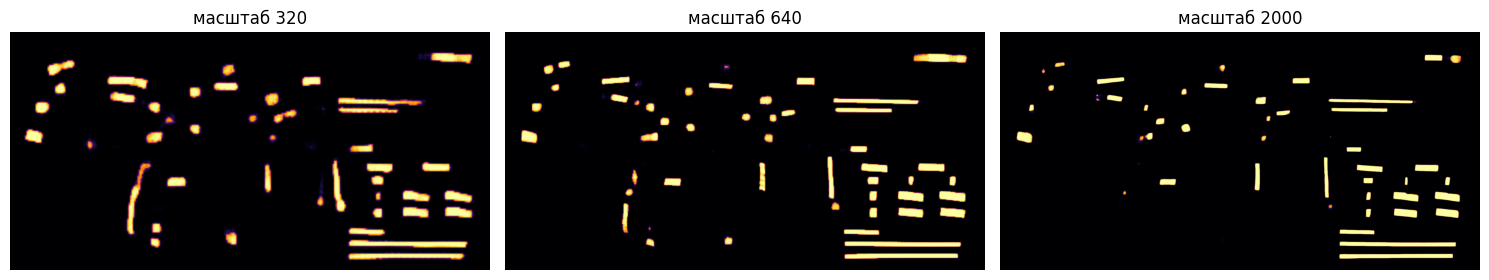

In [343]:
SCALES: tuple[int, ...] = (320, 640, 2000)
prob_stack: Floats = multiscale_prob(img_bgr, SCALES)

fig, axes = plt.subplots(1, len(SCALES), figsize=(5 * len(SCALES), 5))
for ax, prob, scale in zip(axes, prob_stack, SCALES, strict=True):
    ax.imshow(prob, cmap="inferno", vmin=0, vmax=1)
    ax.set_title(f"масштаб {scale}")
    ax.axis("off")
plt.tight_layout()
plt.show()

prob (3378, 6819) | min 0.000 max 1.000


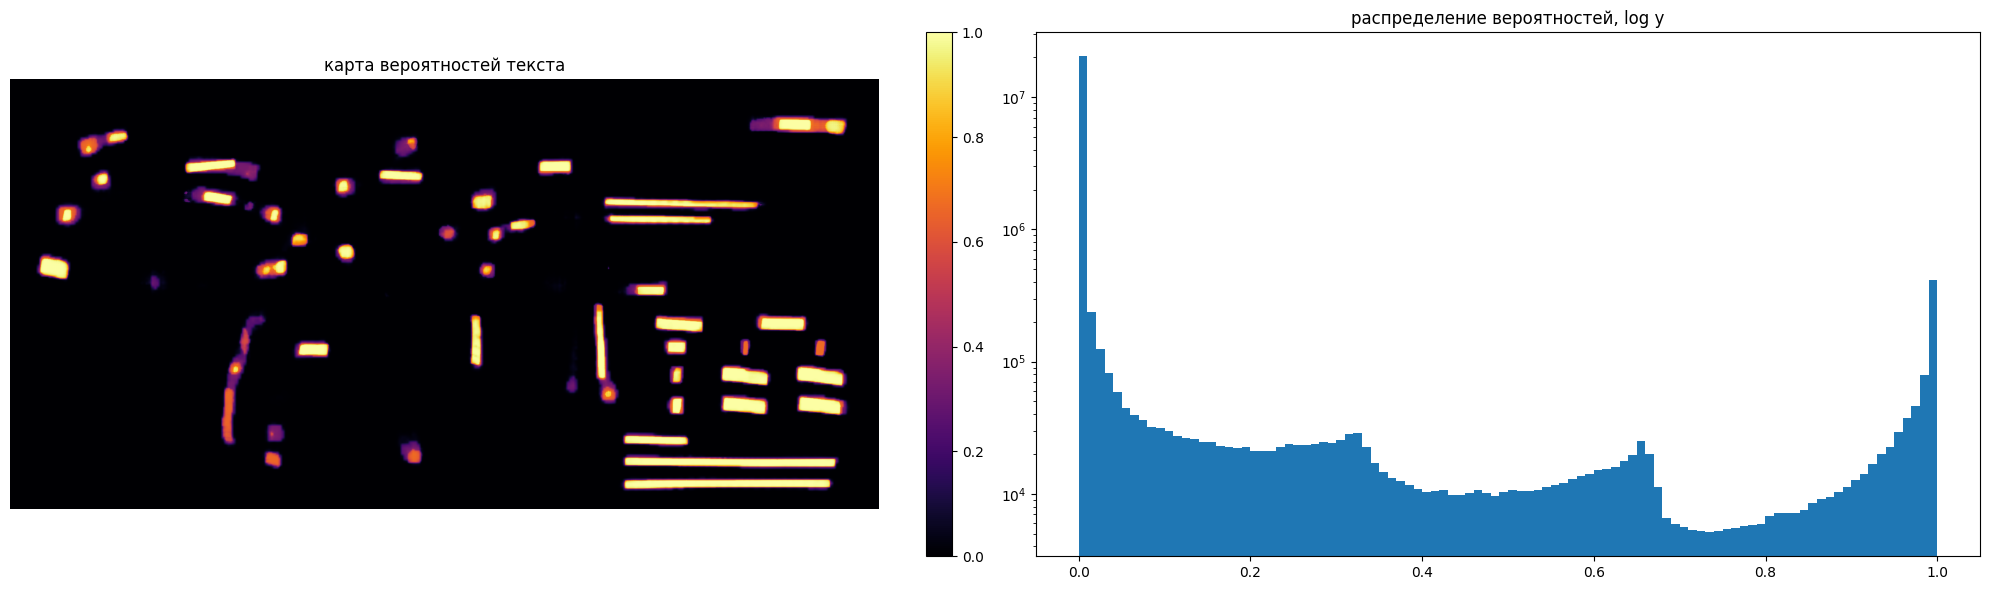

In [344]:
text_prob: Floats = prob_stack.mean(axis=0)
print(f"prob {text_prob.shape} | min {text_prob.min():.3f} max {text_prob.max():.3f}")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(20, 6))
im = a1.imshow(text_prob, cmap="inferno", vmin=0, vmax=1)
a1.set_title("карта вероятностей текста")
a1.axis("off")
fig.colorbar(im, ax=a1, fraction=0.03)
a2.hist(text_prob.ravel(), bins=100, log=True)
a2.set_title("распределение вероятностей, log y")
plt.tight_layout()
plt.show()

Кандидаты по логике DBPostProcess: контуры бинарной карты, minAreaRect, средняя вероятность внутри
прямоугольника. Порог `thresh` отвечает только за связность, решение принимает `box_thresh` по этой
средней. Площадь кандидата тут не участвует вообще.

In [345]:
@dataclass(frozen=True, eq=False)
class Candidates:
    """Кандидаты в текстовые ядра и их метрики."""

    contour: list[Ints]
    score: Floats
    short_side: Floats
    area: Floats
    perimeter: Floats

    def __len__(self) -> int:
        return len(self.contour)


@dataclass(frozen=True, eq=False)
class Kernels:
    """Принятые ядра: только то, что нужно для построения маски."""

    contour: list[Ints]
    area: Floats
    perimeter: Floats

    def __len__(self) -> int:
        return len(self.contour)


def box_score(prob: Floats, box: Floats) -> float:
    """Средняя вероятность внутри четырехугольника, score из DBPostProcess."""
    h, w = prob.shape[:2]
    b = box.copy()
    xmin, xmax = np.clip([np.floor(b[:, 0].min()), np.ceil(b[:, 0].max())], 0, w - 1).astype(np.int32)
    ymin, ymax = np.clip([np.floor(b[:, 1].min()), np.ceil(b[:, 1].max())], 0, h - 1).astype(np.int32)
    m = np.zeros((ymax - ymin + 1, xmax - xmin + 1), dtype=np.uint8)
    b[:, 0] -= xmin
    b[:, 1] -= ymin
    cv2.fillPoly(m, b.reshape(1, -1, 2).astype(np.int32), 1)
    return float(cv2.mean(prob[ymin : ymax + 1, xmin : xmax + 1], m)[0])


def find_candidates(prob: Floats, thresh: float, max_count: int = 1000) -> Candidates:
    """Контуры бинарной карты и их метрики. Решение о приеме принимается отдельно."""
    found, _ = cv2.findContours((prob > thresh).astype(np.uint8), cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    contours = list(found[:max_count])
    rects = [cv2.minAreaRect(c) for c in contours]
    sides = np.array([r[1] for r in rects], dtype=np.float64).reshape(-1, 2)
    return Candidates(
        contour=contours,
        score=np.array([box_score(prob, cv2.boxPoints(r)) for r in rects], dtype=np.float64),
        short_side=sides.min(axis=1) if len(sides) else np.zeros(0),
        area=np.array([cv2.contourArea(c) for c in contours], dtype=np.float64),
        perimeter=np.array([cv2.arcLength(c, True) for c in contours], dtype=np.float64),
    )


def accept_mask(cands: Candidates, box_thresh: float, min_size: float) -> Mask:
    """Прием кандидата: средняя вероятность и минимальная сторона."""
    return (cands.score >= box_thresh) & (cands.short_side >= min_size)


def take_kernels(cands: Candidates, accepted: Mask) -> Kernels:
    """Отбор принятых кандидатов."""
    idx = np.flatnonzero(accepted)
    return Kernels(
        contour=[cands.contour[i] for i in idx],
        area=cands.area[idx],
        perimeter=cands.perimeter[idx],
    )

In [346]:
def report_candidates(cands: Candidates, accepted: Mask) -> None:
    """Отчет по отбору. DataFrame нужен только для печати."""
    print(f"кандидатов {len(cands)} | принято {int(accepted.sum())}")
    if not len(cands):
        return
    table = pd.DataFrame({"score": cands.score, "sside": cands.short_side, "area": cands.area, "keep": accepted})
    print(table.groupby("keep")[["score", "sside", "area"]].median().round(2).to_string())


def draw_candidates(image: Img, cands: Candidates, accepted: Mask, title: str) -> None:
    """Принятые зеленым, отклоненные красным."""
    canvas = image.copy()
    for contour, ok in zip(cands.contour, accepted, strict=True):
        cv2.drawContours(canvas, [contour], -1, (0, 200, 0) if ok else (0, 0, 255), 2)
    show_image(canvas, title, figsize=(18, 10))


def run_candidates(thresh: float, box_thresh: float, min_size: float) -> Kernels:
    """Слайдеры отбора ядер."""
    cands = find_candidates(text_prob, thresh)
    accepted = accept_mask(cands, box_thresh, min_size)
    report_candidates(cands, accepted)
    draw_candidates(img_bgr, cands, accepted, f"ядра: thresh {thresh:.2f} | box_thresh {box_thresh:.2f}")
    return take_kernels(cands, accepted)


ui_cand = interactive(
    run_candidates,
    thresh=FloatSlider(
        value=0.30,
        min=0.05,
        max=0.90,
        step=0.05,
        continuous_update=False,
        description="thresh",
    ),
    box_thresh=FloatSlider(
        value=0.40,
        min=0.10,
        max=0.95,
        step=0.05,
        continuous_update=False,
        description="box_thresh",
    ),
    min_size=FloatSlider(
        value=3.0,
        min=0.0,
        max=20.0,
        step=1.0,
        continuous_update=False,
        description="min сторона",
    ),
)
ui_cand

interactive(children=(FloatSlider(value=0.3, continuous_update=False, description='thresh', max=0.9, min=0.05,…

Маска текстовой области: контур каждого принятого ядра раздувается на `d = area * ratio / perimeter`.
Раздуваем сам контур, а не описанный прямоугольник, форма идет вдоль наклонных надписей и захватывает
меньше лишнего. Бери с запасом: лишний захват линии стоит дешево, пропущенный текст дорого.

In [347]:
def unclip_distance(area: float, perimeter: float, ratio: float) -> int:
    """На сколько пикселей раздуть контур ядра."""
    return int(round(area * ratio / perimeter)) if perimeter > 0 else 0


def dilate_contour(contour: Ints, distance: int, shape: tuple[int, int]) -> Mask:
    """Заливка контура, раздутая на distance. Работает в bbox, а не по всему кадру."""
    h, w = shape
    x, y, bw, bh = cv2.boundingRect(contour)
    pad = distance + 2
    x0, y0 = max(0, x - pad), max(0, y - pad)
    x1, y1 = min(w, x + bw + pad), min(h, y + bh + pad)

    sub = np.zeros((y1 - y0, x1 - x0), np.uint8)
    cv2.drawContours(sub, [contour - np.array([[x0, y0]])], -1, 255, cv2.FILLED)
    if distance > 0:
        far = cv2.distanceTransform(np.where(sub > 0, 0, 255).astype(np.uint8), cv2.DIST_L2, cv2.DIST_MASK_PRECISE)
        sub = np.where((far <= distance) | (sub > 0), 255, 0).astype(np.uint8)

    out = np.zeros(shape, dtype=bool)
    out[y0:y1, x0:x1] = sub > 0
    return out


def build_text_region(kernels: Kernels, ratio: float, shape: tuple[int, int]) -> Mask:
    """Объединение раздутых ядер."""
    region = np.zeros(shape, dtype=bool)
    for contour, area, perimeter in zip(kernels.contour, kernels.area, kernels.perimeter, strict=True):
        region |= dilate_contour(contour, unclip_distance(area, perimeter, ratio), shape)
    return region

In [348]:
def report_region(kernels: Kernels, region: Mask) -> None:
    """Во что развернулись ядра."""
    print(f"ядер {len(kernels)} | область {region.mean() * 100:.3f}% пикселей кадра")


def draw_region(image: Img, region: Mask, title: str) -> None:
    """Полупрозрачная заливка текстовой области."""
    overlay = image.copy()
    overlay[region] = (0, 0, 255)
    show_image(cv2.addWeighted(overlay, 0.45, image, 0.55, 0), title, figsize=(18, 10))


def run_region(unclip_ratio: float) -> Mask:
    """Слайдер раздувания ядер."""
    kernels = ui_cand.result
    region = build_text_region(kernels, unclip_ratio, img_bgr.shape[:2])
    report_region(kernels, region)
    draw_region(img_bgr, region, f"текстовая область: unclip {unclip_ratio:.1f}")
    return region


ui_region = interactive(
    run_region,
    unclip_ratio=FloatSlider(value=1.5, min=0.5, max=4.0, step=0.1, continuous_update=False, description="unclip"),
)
ui_region

interactive(children=(FloatSlider(value=1.5, continuous_update=False, description='unclip', max=4.0, min=0.5),…

## 3. Бинаризация

Штрих темный на светлом, отсюда THRESH_BINARY_INV. Билатеральный фильтр гасит зерно jpeg: без него
тонкие линии рвутся, а разрыв плодит ложные концы в графе. Otsu ставит порог по гистограмме сам.

In [349]:
@dataclass(frozen=True, eq=False)
class Strokes:
    """Штрихи чертежа после бинаризации."""

    gray: Img
    binary: Img
    fg: Mask


def binarize(image: Img) -> Strokes:
    """Otsu по размытой серой картинке."""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.bilateralFilter(gray, d=5, sigmaColor=15, sigmaSpace=15)
    thr, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    print(f"порог Otsu {thr:.0f} | штрихи занимают {(binary > 0).mean():.1%} кадра")
    return Strokes(gray=gray, binary=binary, fg=binary > 0)

порог Otsu 152 | штрихи занимают 5.5% кадра
кадр 13638x6756 | текстовая область 15.18%


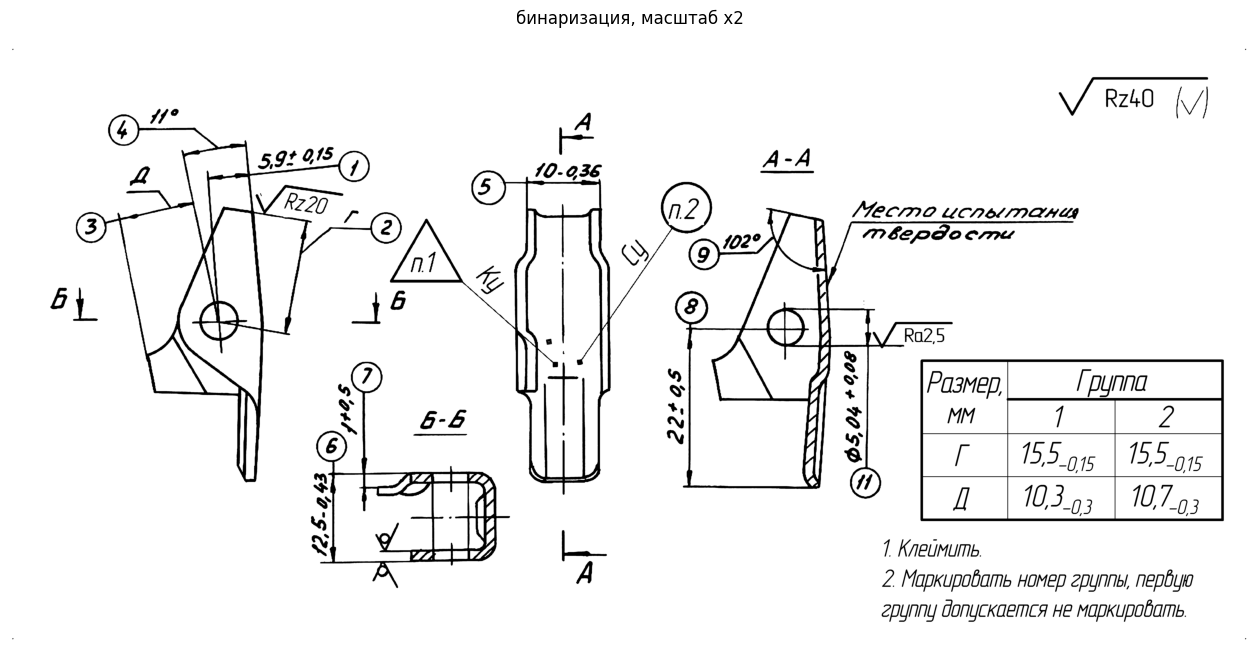

In [350]:
resized: Img = upscale_image(img_bgr, SCALE)
text_region: Mask = upscale_mask(ui_region.result, SCALE)
strokes: Strokes = binarize(resized)

print(f"кадр {resized.shape[1]}x{resized.shape[0]} | текстовая область {text_region.mean() * 100:.2f}%")
show_mask(strokes.fg, f"бинаризация, масштаб x{SCALE:.0f}")

## 4. Граф скелета и толщина штриха

distanceTransform дает расстояние до фона, то есть половину локальной ширины. Значения снимаем
только с медиальной оси: на краях штриха оценка занижена по построению и смазывает гистограмму.
Доля текста считается сразу по пикселям ребра, промежуточного порога на ребре нет.

In [351]:
def group_median(values: Floats, groups: Ints, count: int) -> Floats:
    """Медиана по группам без pandas. Пустая группа -> nan."""
    order = np.lexsort((values, groups))
    sorted_values, sorted_groups = values[order], groups[order]
    starts = np.searchsorted(sorted_groups, np.arange(count), side="left")
    stops = np.searchsorted(sorted_groups, np.arange(count), side="right")
    out = np.full(count, np.nan)
    filled = stops > starts
    out[filled] = sorted_values[((starts + stops) // 2)[filled]]
    return out


def path_thickness(skeleton: Skeleton, dist: Floats, trim: float = 0.25) -> Floats:
    """Толщина ребра = медиана 2r-1 по срединной части: узлы и концы отброшены."""
    n_px = np.diff(skeleton.paths.indptr)
    pid = np.repeat(np.arange(skeleton.n_paths), n_px)
    pos = np.arange(len(pid)) - np.repeat(skeleton.paths.indptr[:-1], n_px)
    inner = (pos >= trim * np.repeat(n_px, n_px)) & (pos < (1 - trim) * np.repeat(n_px, n_px))

    rc = skeleton.coordinates[skeleton.paths.indices].astype(int)
    values = 2 * dist[rc[:, 0], rc[:, 1]] - 1
    return group_median(values[inner], pid[inner], skeleton.n_paths)


def path_id_image(skeleton: Skeleton, shape: tuple[int, int]) -> Ints:
    """Карта пикселей скелета -> id пути, -1 вне скелета."""
    img = np.full(shape, -1, dtype=np.int64)
    rc = skeleton.coordinates[skeleton.paths.indices].astype(int)
    img[rc[:, 0], rc[:, 1]] = np.repeat(np.arange(skeleton.n_paths), np.diff(skeleton.paths.indptr))
    return img


def owner_image(pid: Ints, fg: Mask) -> Ints:
    """Каждый пиксель штриха относим к ближайшему пути скелета, -1 вне штрихов."""
    _, lbl = cv2.distanceTransformWithLabels(
        (pid < 0).astype(np.uint8), cv2.DIST_L2, cv2.DIST_MASK_PRECISE, labelType=cv2.DIST_LABEL_PIXEL
    )
    on_skel = pid >= 0
    lut = np.full(int(lbl.max()) + 1, -1, dtype=np.int64)
    lut[lbl[on_skel]] = pid[on_skel]
    return np.where(fg, lut[lbl], -1)


def path_text_share(skeleton: Skeleton, text_region: Mask) -> Floats:
    """Доля пикселей ребра внутри маски текста. -> (n_paths,)"""
    rc = skeleton.coordinates[skeleton.paths.indices].astype(int)
    pid = np.repeat(np.arange(skeleton.n_paths), np.diff(skeleton.paths.indptr))
    inside = text_region[rc[:, 0], rc[:, 1]].astype(np.float64)
    return np.bincount(pid, weights=inside, minlength=skeleton.n_paths) / np.maximum(np.diff(skeleton.paths.indptr), 1)

In [352]:
@dataclass(frozen=True, eq=False)
class StrokeGraph:
    """Скелет чертежа: ребра, их геометрия и связи."""

    skeleton: Skeleton
    dist: Floats  # distance transform, половина ширины штриха
    pid: Ints  # пиксель скелета -> id пути
    owner: Ints  # пиксель штриха -> id пути
    thickness: Floats  # по ребрам
    length: Floats
    pixels: Ints  # число пикселей оси ребра
    branch: Ints  # тип ребра: 0 изолят, 1 шпора, 2 узел-узел, 3 цикл
    src: Ints
    dst: Ints
    degree: Ints  # степень узла
    text_share: Floats  # доля пикселей ребра в маске текста

    @property
    def n_paths(self) -> int:
        return int(self.skeleton.n_paths)

    @property
    def is_text(self) -> Mask:
        return self.text_share > TEXT_LIMIT

    @property
    def median_thickness(self) -> float:
        return float(np.nanmedian(self.thickness))

    def xy(self, path: int) -> Floats:
        """Точки ребра в порядке (x, y) для matplotlib."""
        return self.skeleton.path_coordinates(path)[:, ::-1]


def build_graph(strokes: Strokes, text_region: Mask) -> StrokeGraph:
    """Скелетизация, толщина каждого ребра и его доля текста."""
    skel = skeletonize(strokes.fg)
    dist = cv2.distanceTransform(strokes.binary, cv2.DIST_L2, cv2.DIST_MASK_PRECISE).astype(np.float64)
    skeleton = Skeleton(skel)
    summary = summarize(skeleton, separator="-")
    pid = path_id_image(skeleton, skel.shape)
    src = summary["node-id-src"].to_numpy()
    dst = summary["node-id-dst"].to_numpy()

    print(f"путей {skeleton.n_paths} | пикселей оси {int(np.diff(skeleton.paths.indptr).sum())}")
    return StrokeGraph(
        skeleton=skeleton,
        dist=dist,
        pid=pid,
        owner=owner_image(pid, strokes.fg),
        thickness=path_thickness(skeleton, dist),
        length=summary["branch-distance"].to_numpy(),
        pixels=np.diff(skeleton.paths.indptr),
        branch=summary["branch-type"].to_numpy(),
        src=src,
        dst=dst,
        degree=np.bincount(np.concatenate([src, dst]), minlength=len(skeleton.coordinates)),
        text_share=path_text_share(skeleton, text_region),
    )

In [353]:
BRANCH_NAMES: dict[int, str] = {0: "конец-конец (изолят)", 1: "узел-конец (шпора)", 2: "узел-узел", 3: "цикл"}


def report_graph(graph: StrokeGraph) -> None:
    """Состав скелета по типам ребер. DataFrame нужен только для печати."""
    short = graph.length < 2 * graph.median_thickness
    table = pd.DataFrame({"branch": graph.branch, "len": graph.length, "short": short, "text": graph.is_text})
    grouped = table.groupby("branch")
    report = pd.DataFrame(
        {
            "n": grouped.size(),
            "len_sum": grouped["len"].sum().round(0),
            "len_share": (grouped["len"].sum() / graph.length.sum()).round(3),
            "n_short": grouped["short"].sum(),
            "n_text": grouped["text"].sum(),
        }
    )
    report.index = [BRANCH_NAMES.get(int(i), str(i)) for i in report.index]

    print(f"ребер {graph.n_paths} | медиана толщины {graph.median_thickness:.1f} px")
    print(report.to_string())
    degrees = graph.degree[graph.degree > 0]
    print(
        f"узлов {len(degrees)} | концов {int((degrees == 1).sum())}"
        f" | deg=2 {int((degrees == 2).sum())} | стыков {int((degrees >= 3).sum())}"
    )
    print(f"текстовых ребер {int(graph.is_text.sum())} ({graph.is_text.mean():.1%})")

In [354]:
graph: StrokeGraph = build_graph(strokes, text_region)
segments: list[Floats] = [graph.xy(i) for i in range(graph.n_paths)]
bounds: Floats = np.array([[s[:, 0].min(), s[:, 0].max(), s[:, 1].min(), s[:, 1].max()] for s in segments])

report_graph(graph)

путей 1236 | пикселей оси 211649
ребер 1236 | медиана толщины 21.6 px
                        n   len_sum  len_share  n_short  n_text
конец-конец (изолят)   91   14953.0      0.065       33      72
узел-конец (шпора)    511   53717.0      0.234      187     402
узел-узел             563  127338.0      0.554      128     145
цикл                   71   33743.0      0.147        0      65
узлов 1291 | концов 693 | deg=2 25 | стыков 573
текстовых ребер 684 (55.3%)


Просмотрщик графа. Окно задается центром и зумом, подписи включаются флажком и печатаются только
если ребер в кадре немного.

In [355]:
def view_window(cx: float, cy: float, zoom: float) -> Window:
    """Окно просмотра -> (x0, x1, y0, y1) в пикселях."""
    h, w = resized.shape[:2]
    half = max(h, w) / (2 * zoom)
    return cx * w - half, cx * w + half, cy * h - half, cy * h + half


def paths_in_window(win: Window) -> Mask:
    """Ребра, задевшие окно. -> (n_paths,)"""
    x0, x1, y0, y1 = win
    return (bounds[:, 0] <= x1) & (bounds[:, 1] >= x0) & (bounds[:, 2] <= y1) & (bounds[:, 3] >= y0)


def nodes_in_window(win: Window) -> Ints:
    """Индексы узлов внутри окна."""
    x0, x1, y0, y1 = win
    y, x = graph.skeleton.coordinates[:, 0], graph.skeleton.coordinates[:, 1]
    return np.flatnonzero((graph.degree > 0) & (x >= x0) & (x <= x1) & (y >= y0) & (y <= y1))


def ax_view(win: Window, title: str, figsize: tuple[float, float] = (18, 11)) -> Axes:
    """Оси с подложкой и выставленным окном."""
    x0, x1, y0, y1 = win
    _, ax = plt.subplots(figsize=figsize)
    ax.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY), cmap="gray", alpha=0.4)
    ax.set_xlim(x0, x1)
    ax.set_ylim(y1, y0)
    ax.axis("off")
    ax.set_title(title)
    return ax


def view_sliders() -> dict[str, FloatSlider]:
    """Одинаковый набор слайдеров окна для любого визуализатора."""
    return dict(
        cx=FloatSlider(value=0.5, min=0.0, max=1.0, step=0.02, continuous_update=False, description="центр X"),
        cy=FloatSlider(value=0.5, min=0.0, max=1.0, step=0.02, continuous_update=False, description="центр Y"),
        zoom=FloatSlider(value=1.0, min=1.0, max=12.0, step=0.5, continuous_update=False, description="зум"),
    )


def draw_paths(ax: Axes, paths: Ints, colors, width: float = 1.8, dashed: Mask | None = None, zorder: int = 2) -> None:
    """Отрисовка ребер скелета одним LineCollection."""
    styles = np.where(dashed, "dashed", "solid").tolist() if dashed is not None else "solid"
    ax.add_collection(
        LineCollection([segments[i] for i in paths], colors=colors, linewidths=width, linestyles=styles, zorder=zorder)
    )

In [356]:
NODE_KINDS: tuple[tuple[int, int, str, str, str], ...] = (
    (1, 1, "red", "o", "конец"),
    (2, 2, "yellow", "^", "deg=2"),
    (3, 99, "cyan", "s", "стык"),
)


def draw_nodes(ax: Axes, nodes: Ints) -> None:
    """Узлы по степени: свободный конец, deg=2, стык."""
    for lo, hi, color, marker, name in NODE_KINDS:
        sel = nodes[(graph.degree[nodes] >= lo) & (graph.degree[nodes] <= hi)]
        ax.scatter(
            graph.skeleton.coordinates[sel, 1],
            graph.skeleton.coordinates[sel, 0],
            s=26,
            c=color,
            marker=marker,
            edgecolors="k",
            linewidths=0.4,
            zorder=3,
            label=f"{name} {len(sel)}",
        )


def draw_path_labels(ax: Axes, paths: Ints, limit: int = 80) -> None:
    """Подписи id, длины и толщины у видимых ребер."""
    if len(paths) > limit:
        print(f"подписи скрыты: ребер {len(paths)} > {limit}, добавь зум или min_len")
        return
    for i in paths:
        x, y = segments[i][len(segments[i]) // 2]
        ax.text(x, y, f"{i}\n{graph.length[i]:.0f}/{graph.thickness[i]:.1f}", fontsize=7, ha="center", va="center")


def report_window(paths: Ints, nodes: Ints) -> None:
    """Состав кадра."""
    if len(paths):
        print(
            f"ребер в кадре {len(paths)} | длины: медиана {np.median(graph.length[paths]):.0f}, max {graph.length[paths].max():.0f}"
        )
    else:
        print("ребер в кадре нет")
    print(f"узлов {len(nodes)} | текстовых ребер {int(graph.is_text[paths].sum())}")


def run_graph(cx: float, cy: float, zoom: float, min_len: int, labels: bool) -> None:
    """Ребра случайными цветами, узлы по степени, пунктир у текстовых."""
    win = view_window(cx, cy, zoom)
    paths = np.flatnonzero(paths_in_window(win) & (graph.length >= min_len))
    nodes = nodes_in_window(win)
    report_window(paths, nodes)

    ax = ax_view(win, f"граф скелета | зум {zoom:.1f}x | пунктир это текст | подпись: id / длина / толщина")
    draw_paths(ax, paths, path_colors[paths], dashed=graph.is_text[paths])
    draw_nodes(ax, nodes)
    if labels:
        draw_path_labels(ax, paths)
    ax.legend(loc="upper right", fontsize=8)
    plt.show()


path_colors: Floats = plt.cm.hsv(np.random.default_rng(0).random(graph.n_paths))
ui_graph = interactive(
    run_graph,
    **view_sliders(),
    min_len=IntSlider(value=0, min=0, max=60, step=1, continuous_update=False, description="min len, px"),
    labels=Checkbox(value=False, description="подписи"),
)
ui_graph

interactive(children=(FloatSlider(value=0.5, continuous_update=False, description='центр X', max=1.0, step=0.0…

## 5. Склейка ребер в цепи

Скелет рвет линию на ребра в каждом пересечении. Цепь собирает их обратно: два конца в одном
супер-узле склеиваются, если продолжают друг друга по направлению, лежат на одной прямой и близки
по толщине. Самокольца остаются в выборке, иначе теряются буквы 0 и О и кружки позиций.

In [357]:
@dataclass(frozen=True)
class Gates:
    """Ворота склейки пары концов."""

    max_dev: float = 20.0  # отклонение от прямой, градусы
    max_off: float = 7.5  # поперечный сдвиг, px
    t_ratio: float = 1.6  # допустимое отношение толщин


@dataclass(frozen=True)
class MergeParams:
    """Параметры шага склейки."""

    r_node: float = 8.0  # радиус схлопывания стыков в супер-узел
    tan_len: int = 12  # длина участка для оценки касательной
    gates: Gates = Gates()


@dataclass(frozen=True, eq=False)
class SuperNodes:
    """Стыки, соединенные коротким ребром, схлопнуты в один узел."""

    label: Ints  # узел -> метка супер-узла
    absorbed: Mask  # ребра, поглощенные супер-узлом


def build_super_nodes(graph: StrokeGraph, r_node: float) -> SuperNodes:
    """Схлопывание близких стыков."""
    absorbed = (graph.length < r_node) & (graph.degree[graph.src] >= 3) & (graph.degree[graph.dst] >= 3)
    n = len(graph.skeleton.coordinates)
    g = coo_matrix((np.ones(absorbed.sum()), (graph.src[absorbed], graph.dst[absorbed])), shape=(n, n))
    return SuperNodes(label=connected_components(g, directed=False)[1], absorbed=absorbed)


def end_tangents(graph: StrokeGraph, tan_len: int) -> Floats:
    """Направление в каждом конце ребра, от узла внутрь. -> (n_paths, 2, 2) в (dy, dx)"""
    out = np.zeros((graph.n_paths, 2, 2))
    for i in range(graph.n_paths):
        coords = graph.skeleton.path_coordinates(i).astype(float)
        k = max(2, min(int(tan_len), len(coords)))
        for side in (0, 1):
            pts = coords[:k] if side == 0 else coords[::-1][:k]
            u = np.linalg.svd(pts - pts.mean(0), full_matrices=False)[2][0]
            out[i, side] = u if u @ (pts[-1] - pts[0]) > 0 else -u
    return out

In [358]:
@dataclass(frozen=True, eq=False)
class Ends:
    """Концы ребер, участвующих в склейке. Все массивы одной длины."""

    path: Ints
    node: Ints  # метка супер-узла
    degree: Ints
    point: Floats  # (n, 2) в (y, x)
    direction: Floats  # (n, 2) наружу из ребра
    thickness: Floats

    def __len__(self) -> int:
        return len(self.path)


def build_ends(graph: StrokeGraph, paths: Ints, nodes: SuperNodes, tangents: Floats) -> Ends:
    """Таблица концов: по два конца на каждое ребро из paths."""
    path = np.repeat(paths, 2)
    side = np.tile(np.array([0, 1]), len(paths))
    raw_node = np.where(side == 0, graph.src[path], graph.dst[path])
    point = np.array(
        [graph.skeleton.path_coordinates(p)[0 if s == 0 else -1] for p, s in zip(path, side, strict=True)], dtype=float
    )
    return Ends(
        path=path,
        node=nodes.label[raw_node],
        degree=graph.degree[raw_node],
        point=point,
        direction=tangents[path, side],
        thickness=graph.thickness[path],
    )


def perp_offset(pa: Floats, da: Floats, pb: Floats, db: Floats) -> float:
    """Насколько конец b не лежит на прямой конца a, и наоборот."""
    v = pb - pa
    return float(max(abs(v[0] * da[1] - v[1] * da[0]), abs(v[0] * db[1] - v[1] * db[0])))


def thickness_ok(ta: float, tb: float, ratio: float) -> bool:
    """Толщины сопоставимы, nan пропускаем."""
    if not (np.isfinite(ta) and np.isfinite(tb)):
        return True
    return max(ta, tb) <= ratio * max(min(ta, tb), 1e-6)


def pair_deviation(ends: Ends, a: int, b: int, gates: Gates, off_scale: float = 1.0) -> float | None:
    """Отклонение пары от прямой в градусах или None, если ворота не пройдены."""
    dev = float(np.degrees(np.arccos(np.clip(-float(ends.direction[a] @ ends.direction[b]), -1.0, 1.0))))
    off = perp_offset(ends.point[a], ends.direction[a], ends.point[b], ends.direction[b])
    if dev > gates.max_dev or off > off_scale * gates.max_off:
        return None
    if not thickness_ok(ends.thickness[a], ends.thickness[b], gates.t_ratio):
        return None
    return dev


def group_by_node(ends: Ends) -> list[Ints]:
    """Индексы концов, сгруппированные по супер-узлу."""
    order = np.argsort(ends.node, kind="stable")
    return np.split(order, np.flatnonzero(np.diff(ends.node[order])) + 1)


def candidate_pairs(ends: Ends, gates: Gates) -> list[tuple[int, int]]:
    """Пары концов внутри супер-узла, прошедшие ворота. Самые прямые первыми."""
    scored: list[tuple[float, int, int]] = []
    for group in group_by_node(ends):
        for a, b in combinations(group.tolist(), 2):
            if ends.path[a] == ends.path[b]:
                continue
            dev = pair_deviation(ends, a, b, gates)
            if dev is not None:
                scored.append((dev, a, b))
    scored.sort()
    return [(a, b) for _, a, b in scored]


def greedy_match(pairs: list[tuple[int, int]], n_ends: int) -> list[tuple[int, int]]:
    """Жадное паросочетание: каждый конец участвует один раз."""
    taken = np.zeros(n_ends, dtype=bool)
    matched: list[tuple[int, int]] = []
    for a, b in pairs:
        if not (taken[a] or taken[b]):
            taken[a] = taken[b] = True
            matched.append((a, b))
    return matched

In [359]:
@dataclass(frozen=True, eq=False)
class Chains:
    """Цепи: ребра, собранные обратно в линии."""

    n_paths: int  # размер скелета, чтобы разворачивать решения по цепям в маску путей
    paths: Ints  # id ребер, попавших в цепи
    label: Ints  # метка цепи для каждого элемента paths
    length: Floats  # по цепям
    thickness: Floats
    text_share: Floats

    @property
    def count(self) -> int:
        return len(self.length)

    @property
    def is_text(self) -> Mask:
        return self.text_share > TEXT_LIMIT

    def path_mask(self, keep: Mask) -> Mask:
        """Решение по цепям -> маска ребер скелета. -> (n_paths,)"""
        mask = np.zeros(self.n_paths, dtype=bool)
        mask[self.paths] = keep[self.label]
        return mask


def weighted_median(values: Floats, weights: Floats) -> float:
    """Медиана, взвешенная длиной звена."""
    finite = np.isfinite(values)
    values, weights = values[finite], weights[finite]
    if not len(values):
        return float("nan")
    order = np.argsort(values)
    cumulative = np.cumsum(weights[order])
    return float(values[order][np.searchsorted(cumulative, 0.5 * cumulative[-1])])


def chain_labels(pairs: list[tuple[int, int]], ends: Ends, paths: Ints, n_paths: int) -> Ints:
    """Склеенные ребра -> метка цепи для каждого элемента paths."""
    pos = np.full(n_paths, -1)
    pos[paths] = np.arange(len(paths))
    rows = [pos[ends.path[a]] for a, b in pairs]
    cols = [pos[ends.path[b]] for a, b in pairs]
    g = coo_matrix((np.ones(len(rows)), (rows, cols)), shape=(len(paths), len(paths)))
    return connected_components(g, directed=False)[1]


def chain_thickness(label: Ints, thickness: Floats, length: Floats, count: int) -> Floats:
    """Толщина цепи = медиана толщин звеньев, взвешенная их длиной."""
    out = np.full(count, np.nan)
    for c in range(count):
        members = label == c
        out[c] = weighted_median(thickness[members], length[members])
    return out


def chain_text_share(label: Ints, text_share: Floats, pixels: Ints, count: int) -> Floats:
    """Доля пикселей цепи в маске текста. Порог применяется один раз, уже к цепи."""
    inside = np.bincount(label, weights=text_share * pixels, minlength=count)
    total = np.bincount(label, weights=pixels.astype(np.float64), minlength=count)
    return inside / np.maximum(total, 1.0)


def build_chains(graph: StrokeGraph, params: MergeParams) -> Chains:
    """Склейка ребер в цепи по прямизне, сдвигу и толщине."""
    nodes = build_super_nodes(graph, params.r_node)
    paths = np.flatnonzero(~nodes.absorbed)  # самокольца остаются, поглощенные стыком нет
    ends = build_ends(graph, paths, nodes, end_tangents(graph, params.tan_len))
    matched = greedy_match(candidate_pairs(ends, params.gates), len(ends))
    label = chain_labels(matched, ends, paths, graph.n_paths)
    count = int(label.max()) + 1

    print(f"ребер {graph.n_paths} | в склейке {len(paths)} | склеено пар {len(matched)} -> цепей {count}")
    return Chains(
        n_paths=graph.n_paths,
        paths=paths,
        label=label,
        length=np.bincount(label, weights=graph.length[paths], minlength=count),
        thickness=chain_thickness(label, graph.thickness[paths], graph.length[paths], count),
        text_share=chain_text_share(label, graph.text_share[paths], graph.pixels[paths], count),
    )

In [360]:
def report_chains(graph: StrokeGraph, chains: Chains) -> None:
    """Во что схлопнулся граф."""
    table = pd.DataFrame({"len": chains.length, "t": chains.thickness, "text": chains.text_share})
    print(
        f"цепей {chains.count} | текстовых {int(chains.is_text.sum())} | звеньев на цепь {len(chains.paths) / chains.count:.2f}"
    )
    print(
        f"длина: было медиана {np.median(graph.length[chains.paths]):.0f} -> стало {np.median(chains.length):.0f}, max {chains.length.max():.0f}"
    )
    print("\n5 самых длинных цепей:")
    print(table.sort_values("len", ascending=False).head(5).round(2).to_string())


def draw_chains(win: Window, chains: Chains, title: str) -> None:
    """Один цвет это одна цепь."""
    ax = ax_view(win, title)
    visible = paths_in_window(win)[chains.paths]
    colors = plt.cm.hsv(np.random.default_rng(1).permutation(chains.count) / max(chains.count - 1, 1))
    draw_paths(ax, chains.paths[visible], colors[chains.label[visible]], width=2.0)
    plt.show()


def run_merge(
    cx: float, cy: float, zoom: float, r_node: float, tan_len: int, max_dev: float, max_off: float, t_ratio: float
) -> Chains:
    """Слайдеры склейки."""
    params = MergeParams(r_node=r_node, tan_len=tan_len, gates=Gates(max_dev, max_off, t_ratio))
    chains = build_chains(graph, params)
    report_chains(graph, chains)
    draw_chains(
        view_window(cx, cy, zoom),
        chains,
        f"цепи | r={r_node} tan={tan_len} | dev<{max_dev} град, off<{max_off} px, t<{t_ratio}x",
    )
    return chains


ui_merge = interactive(
    run_merge,
    **view_sliders(),
    r_node=FloatSlider(value=8.0, min=0.0, max=20.0, step=0.5, continuous_update=False, description="r узла, px"),
    tan_len=IntSlider(value=12, min=3, max=40, step=1, continuous_update=False, description="касат., px"),
    max_dev=FloatSlider(value=20.0, min=0.0, max=45.0, step=1.0, continuous_update=False, description="угол, град"),
    max_off=FloatSlider(value=7.5, min=0.0, max=20.0, step=0.5, continuous_update=False, description="сдвиг, px"),
    t_ratio=FloatSlider(value=1.6, min=1.0, max=3.0, step=0.1, continuous_update=False, description="t max/min"),
)
ui_merge

interactive(children=(FloatSlider(value=0.5, continuous_update=False, description='центр X', max=1.0, step=0.0…

In [361]:
chains: Chains = ui_merge.result
print(f"цепей {chains.count} | звеньев {len(chains.paths)} | текстовых цепей {int(chains.is_text.sum())}")

цепей 994 | звеньев 1197 | текстовых цепей 617


Диагностика разрывов: встречные свободные концы нетекстовых ребер, которые не попали в одну цепь.
Граф они не меняют, это только счет незакрытых стыков.

In [362]:
def find_gaps(graph: StrokeGraph, params: MergeParams, gap_r: float) -> Floats:
    """Пары точек незакрытых разрывов. -> (n, 2, 2) в (y, x)"""
    nodes = build_super_nodes(graph, params.r_node)
    paths = np.flatnonzero(~nodes.absorbed)
    ends = build_ends(graph, paths, nodes, end_tangents(graph, params.tan_len))
    free = np.flatnonzero((ends.degree == 1) & (graph.text_share[ends.path] <= TEXT_LIMIT))
    if len(free) < 2 or gap_r <= 0:
        print("свободных концов нет или радиус нулевой")
        return np.zeros((0, 2, 2))

    found: list[list[Floats]] = []
    for a, b in cKDTree(ends.point[free]).query_pairs(gap_r):
        i, j = int(free[a]), int(free[b])
        towards = -ends.direction[i] @ (ends.point[j] - ends.point[i]) > 0
        if towards and pair_deviation(ends, i, j, params.gates, off_scale=2.0) is not None:
            found.append([ends.point[i], ends.point[j]])
    print(f"свободных концов {len(free)} | встречных пар в радиусе {gap_r:.0f} px: {len(found)}")
    return np.array(found) if found else np.zeros((0, 2, 2))


def draw_gaps(win: Window, gaps: Floats, title: str) -> None:
    """Красный пунктир на месте разрыва."""
    ax = ax_view(win, title)
    draw_paths(ax, chains.paths, "0.6", width=1.0)
    if len(gaps):
        ax.add_collection(
            LineCollection(
                [[p[::-1], q[::-1]] for p, q in gaps], colors="red", linewidths=1.6, linestyles="dashed", zorder=5
            )
        )
    plt.show()


def run_gaps(cx: float, cy: float, zoom: float, gap_r: float) -> Floats:
    """Слайдер радиуса поиска разрывов."""
    gaps = find_gaps(graph, MergeParams(), gap_r)
    draw_gaps(view_window(cx, cy, zoom), gaps, f"разрывы в радиусе {gap_r:.0f} px: {len(gaps)}")
    return gaps


ui_gaps = interactive(
    run_gaps,
    **view_sliders(),
    gap_r=FloatSlider(value=12.0, min=0.0, max=40.0, step=1.0, continuous_update=False, description="радиус, px"),
)
ui_gaps

interactive(children=(FloatSlider(value=0.5, continuous_update=False, description='центр X', max=1.0, step=0.0…

## 6. Классы толщины

Одномерный KMeans по толщине цепей. Текст и цепи с неопределенной толщиной в обучении не участвуют,
иначе буквы стягивают границы классов вниз.

In [363]:
@dataclass(frozen=True, eq=False)
class ThicknessClasses:
    """Классы толщины, пронумерованные по возрастанию."""

    label: Ints  # по цепям, -1 это текст или nan
    centers: Floats
    edges: Floats  # границы между соседними классами


def fit_classes(chains: Chains, k: int, weighted: bool) -> ThicknessClasses:
    """KMeans по толщине цепей. Обучение только на детали."""
    usable = np.isfinite(chains.thickness) & ~chains.is_text
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(
        chains.thickness[usable, None], sample_weight=chains.length[usable] if weighted else None
    )
    order = np.argsort(km.cluster_centers_.ravel())
    rank = np.empty(k, dtype=int)
    rank[order] = np.arange(k)
    centers = km.cluster_centers_.ravel()[order]

    label = np.full(chains.count, -1, dtype=np.int64)
    label[usable] = rank[km.labels_]
    print(f"обучено на {int(usable.sum())} цепях из {chains.count}")
    return ThicknessClasses(label=label, centers=centers, edges=(centers[:-1] + centers[1:]) / 2)


def report_classes(chains: Chains, classes: ThicknessClasses) -> None:
    """Центры, границы и наполнение классов."""
    print(f"центры, px:  {np.round(classes.centers, 2)} | в оригинале {np.round(classes.centers / SCALE, 2)}")
    print(f"границы, px: {np.round(classes.edges, 2)} | в оригинале {np.round(classes.edges / SCALE, 2)}")
    total = chains.length[classes.label >= 0].sum()
    for c in range(len(classes.centers)):
        members = classes.label == c
        print(
            f"класс {c}: цепей {int(members.sum())} | длина {chains.length[members].sum() / total:.1%}"
            f" | t от {chains.thickness[members].min():.1f} до {chains.thickness[members].max():.1f}"
        )


def draw_classes(chains: Chains, classes: ThicknessClasses, title: str) -> None:
    """Цвет по классу толщины, текст серым."""
    palette = np.array(PALETTE[: len(classes.centers)], dtype=float) / 255
    colors = np.where(
        (classes.label < 0)[chains.label][:, None],
        np.array([0.55, 0.55, 0.55]),
        palette[classes.label.clip(0)[chains.label]],
    )
    fig, ax = plt.subplots(figsize=(18, 10))
    ax.imshow(resized[..., ::-1])
    draw_paths(ax, chains.paths, colors, width=1.2)
    ax.axis("off")
    ax.set_title(title)
    plt.show()

In [364]:
def run_classes(k: int, weighted: bool) -> ThicknessClasses:
    """Слайдер числа классов."""
    classes = fit_classes(chains, k, weighted)
    report_classes(chains, classes)
    draw_classes(chains, classes, f"{k} классов | границы {np.round(classes.edges, 1)} px")
    return classes


ui_cls = interactive(
    run_classes,
    k=IntSlider(value=2, min=2, max=6, step=1, continuous_update=False, description="классов"),
    weighted=Checkbox(value=True, description="вес по длине"),
)
ui_cls

interactive(children=(IntSlider(value=2, continuous_update=False, description='классов', max=6, min=2), Checkb…

In [365]:
classes: ThicknessClasses = ui_cls.result
print(f"классов {len(classes.centers)} | цепей без класса {int((classes.label < 0).sum())}")

классов 2 | цепей без класса 617


## 7. Перерисовка сохраненных линий

Удалять пиксели нельзя: карта owner делит пиксели между ребрами по близости, и в месте, где тонкая
линия упирается в контур, часть пикселей контура принадлежит тонкому ребру. Поэтому сохраненные
линии рисуются заново от своей оси, каждая осевая точка раздувается на собственный радиус из dist.
Удаленное исчезает не вычитанием, а тем, что его просто не рисуют.

In [366]:
def keep_by_class(chains: Chains, classes: ThicknessClasses, class_min: int) -> Mask:
    """Цепи класса class_min и выше, не текст."""
    return (classes.label >= class_min) & ~chains.is_text


def paint_paths(graph: StrokeGraph, keep_paths: Mask, fg: Mask, tol: float) -> Mask:
    """Заливка сохраненных линий от их оси. Ширина берется в ближайшей осевой точке."""
    kept_skel = (graph.pid >= 0) & keep_paths[np.maximum(graph.pid, 0)]
    if not kept_skel.any():
        return np.zeros_like(fg)

    far, lbl = cv2.distanceTransformWithLabels(
        (~kept_skel).astype(np.uint8), cv2.DIST_L2, cv2.DIST_MASK_PRECISE, labelType=cv2.DIST_LABEL_PIXEL
    )
    radius = np.zeros(int(lbl.max()) + 1, dtype=np.float32)
    radius[lbl[kept_skel]] = graph.dist[kept_skel]
    return fg & (far <= radius[lbl] + tol)


def cut_by_owner(graph: StrokeGraph, keep_paths: Mask, fg: Mask) -> Mask:
    """Что удалил бы наивный подход через owner. Нужно только для контроля."""
    return fg & (graph.owner >= 0) & ~keep_paths[np.maximum(graph.owner, 0)]

In [367]:
def report_clean(chains: Chains, keep: Mask, mask: Mask, fg: Mask, rescued: Mask) -> None:
    """Сколько осталось и сколько спасла перерисовка."""
    components = cv2.connectedComponents(mask.astype(np.uint8) * 255)[0] - 1
    print(f"цепей {int(keep.sum())}/{chains.count} | длины {chains.length[keep].sum() / chains.length.sum():.1%}")
    print(f"чернил {mask.sum() / fg.sum():.1%} | компонент {components}")
    print(f"спасено от выкусывания {int(rescued.sum())} px на стыках")


def draw_clean(image: Img, fg: Mask, mask: Mask, rescued: Mask, title: str) -> None:
    """Слева удаленное красным и спасенное зеленым, справа результат."""
    # overlay = image.copy()
    # overlay[fg & ~mask] = (60, 60, 255)
    # overlay[rescued] = (0, 200, 0)

    # fig, (a1, a2) = plt.subplots(1, 2, figsize=(20, 8))
    # a1.imshow(overlay[..., ::-1])
    # a1.set_title("красное убрано, зеленое спасено перерисовкой")
    # a2.imshow(np.where(mask, 0, 255).astype(np.uint8), cmap="gray")
    # a2.set_title(title)
    # for ax in (a1, a2):
    #     ax.axis("off")

    plt.figure(figsize=(20, 8))
    plt.imshow(np.where(mask, 0, 255).astype(np.uint8), cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()


def run_clean(class_min: int, tol: float) -> Mask:
    """Слайдеры финальной маски."""
    keep = keep_by_class(chains, classes, class_min)
    keep_paths = chains.path_mask(keep)
    mask = paint_paths(graph, keep_paths, strokes.fg, tol)
    rescued = mask & cut_by_owner(graph, keep_paths, strokes.fg)
    report_clean(chains, keep, mask, strokes.fg, rescued)
    draw_clean(resized, strokes.fg, mask, rescued, f"классы >= {class_min}, допуск {tol:.1f} px")
    return mask


ui_clean = interactive(
    run_clean,
    class_min=IntSlider(value=1, min=0, max=5, step=1, continuous_update=False, description="класс >="),
    tol=FloatSlider(value=0.5, min=0.0, max=2.0, step=0.1, continuous_update=False, description="допуск, px"),
)
ui_clean

interactive(children=(IntSlider(value=1, continuous_update=False, description='класс >=', max=5), FloatSlider(…

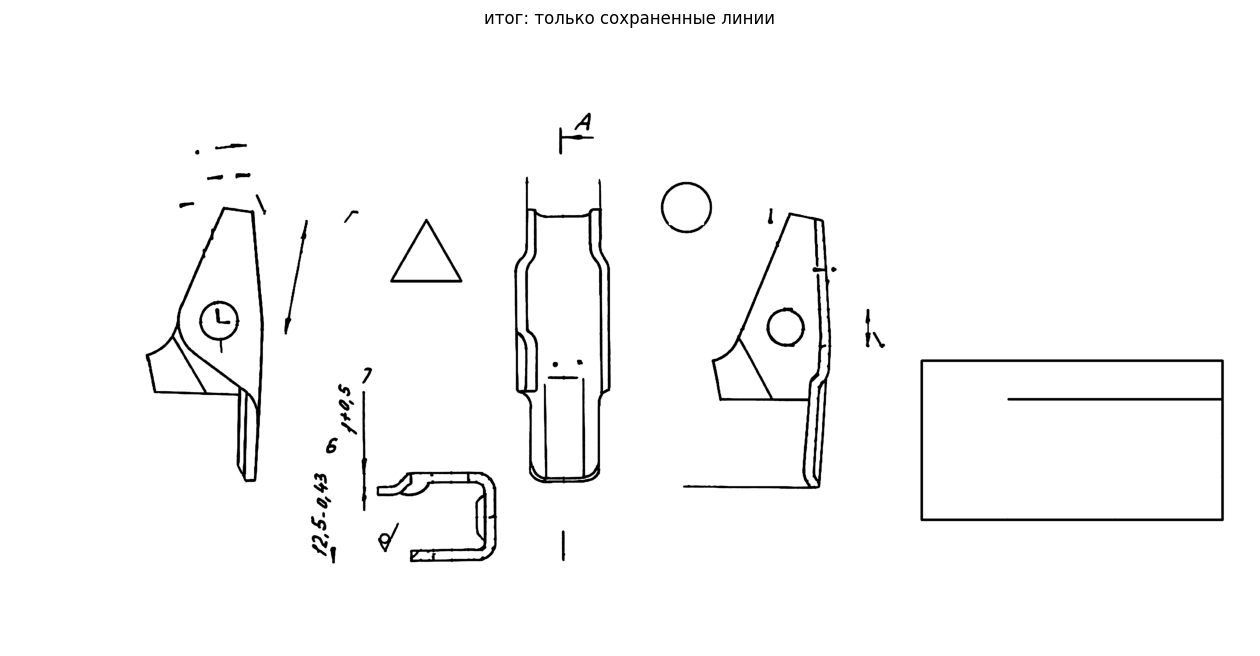

In [380]:
clean_mask: Mask = ui_clean.result
show_mask(clean_mask, "итог: только сохраненные линии")

In [383]:
@dataclass(frozen=True, eq=False)
class Blobs:
    """Связные куски маски и их топология, посчитанные по самой маске."""

    label: Ints  # карта пикселей -> id куска, 0 это фон
    area: Ints  # площадь куска в пикселях штриха
    closed: Mask  # внутри есть замкнутая пустота

    @property
    def count(self) -> int:
        return len(self.area)


def fill_holes(mask: Mask) -> Mask:
    """Заливка внутренних пустот: фон, недостижимый от края кадра."""
    padded = np.zeros((mask.shape[0] + 2, mask.shape[1] + 2), np.uint8)
    padded[1:-1, 1:-1] = (~mask).astype(np.uint8) * 255
    cv2.floodFill(padded, np.zeros((padded.shape[0] + 2, padded.shape[1] + 2), np.uint8), (0, 0), 0)
    return mask | (padded[1:-1, 1:-1] > 0)


def build_blobs(mask: Mask) -> Blobs:
    """Куски маски с признаком замкнутости. Дыра приписывается тому куску, который ее окружает."""
    filled = fill_holes(mask)
    count, label = cv2.connectedComponents(filled.astype(np.uint8), connectivity=8)
    holes = filled & ~mask

    closed = np.zeros(count, dtype=bool)
    closed[label[holes]] = True
    closed[0] = False  # фон

    print(
        f"кусков {count - 1} | замкнутых {int(closed.sum())} | дыр {int(cv2.connectedComponents(holes.astype(np.uint8))[0] - 1)}"
    )
    return Blobs(label=label.astype(np.int64), area=np.bincount(label[mask], minlength=count), closed=closed)


def select_blobs(blobs: Blobs, min_area: int) -> Mask:
    """Фигура это замкнутый кусок достаточной площади."""
    keep = blobs.closed & (blobs.area >= min_area)
    keep[0] = False
    return keep


In [384]:
def report_blobs(blobs: Blobs, keep: Mask) -> None:
    """Что признано фигурой, а что выброшено. DataFrame нужен только для печати."""
    table = pd.DataFrame({"area": blobs.area, "closed": blobs.closed, "figure": keep})
    alive = table[table.area > 0]
    print(
        f"кусков {len(alive)} | фигур {int(keep.sum())} | их доля чернил {alive[alive.figure].area.sum() / alive.area.sum():.1%}"
    )
    print("\n5 самых крупных выброшенных:")
    print(alive[~alive.figure].sort_values("area", ascending=False).head(5).to_string())


def draw_blobs(image: Img, mask: Mask, result: Mask, title: str) -> None:
    """Слева выброшенное красным, справа результат."""
    overlay = image.copy()
    overlay[mask & ~result] = (60, 60, 255)

    fig, (a1, a2) = plt.subplots(1, 2, figsize=(20, 8))
    a1.imshow(overlay[..., ::-1])
    a1.set_title("красное это незамкнутые куски")
    a2.imshow(np.where(result, 0, 255).astype(np.uint8), cmap="gray")
    a2.set_title(title)
    for ax in (a1, a2):
        ax.axis("off")
    plt.show()


def run_figures(min_area: int) -> Mask:
    """Слайдер минимальной площади замкнутой фигуры."""
    blobs = build_blobs(clean_mask)
    keep = select_blobs(blobs, min_area)
    result = clean_mask & keep[blobs.label]
    report_blobs(blobs, keep)
    draw_blobs(resized, clean_mask, result, f"замкнутые фигуры от {min_area} px")
    return result


ui_figures = interactive(
    run_figures,
    min_area=IntSlider(
        value=200,
        min=0,
        max=5000,
        step=100,
        continuous_update=False,
        description="площадь >=",
    ),
)
ui_figures


interactive(children=(IntSlider(value=200, continuous_update=False, description='площадь >=', max=5000, step=1…

In [374]:
@dataclass(frozen=True, eq=False)
class Figures:
    """Связные куски сохраненных линий и их топология."""

    component: Ints  # по ребрам скелета: id компоненты или -1
    edges: Ints  # ребер в компоненте
    nodes: Ints  # узлов в компоненте
    length: Floats  # суммарная длина, px

    @property
    def cycles(self) -> Ints:
        """Цикломатическое число: сколько независимых замкнутых путей."""
        return self.edges - self.nodes + 1

    def path_mask(self, keep: Mask) -> Mask:
        """Решение по компонентам -> маска ребер скелета."""
        return (self.component >= 0) & keep[np.maximum(self.component, 0)]


def build_figures(graph: StrokeGraph, keep_paths: Mask) -> Figures:
    """Компоненты связности сохраненных ребер. Самокольцо это V=1, E=1, то есть цикл."""
    paths = np.flatnonzero(keep_paths)
    n = len(graph.skeleton.coordinates)
    g = coo_matrix((np.ones(len(paths)), (graph.src[paths], graph.dst[paths])), shape=(n, n))
    n_comp, node_label = connected_components(g, directed=False)

    touched = np.zeros(n, dtype=bool)
    touched[graph.src[paths]] = True
    touched[graph.dst[paths]] = True

    component = np.full(graph.n_paths, -1, dtype=np.int64)
    component[paths] = node_label[graph.src[paths]]
    return Figures(
        component=component,
        edges=np.bincount(component[paths], minlength=n_comp),
        nodes=np.bincount(node_label[touched], minlength=n_comp),
        length=np.bincount(component[paths], weights=graph.length[paths], minlength=n_comp),
    )


def select_figures(figures: Figures, min_length: float) -> Mask:
    """Фигура это компонента с замкнутым путем и достаточной длиной."""
    return (figures.cycles >= 1) & (figures.length >= min_length)


In [ ]:
def report_figures(figures: Figures, keep: Mask) -> None:
    """Что признано фигурой, а что выброшено. DataFrame нужен только для печати."""
    table = pd.DataFrame({"len": figures.length, "edges": figures.edges, "cycles": figures.cycles, "figure": keep})
    alive = table[table.len > 0]
    print(
        f"компонент {len(alive)} | фигур {int(keep[alive.index].sum())} | длина фигур {alive[alive.figure].len.sum() / alive.len.sum():.1%}"
    )
    print("\n5 самых длинных выброшенных:")
    print(alive[~alive.figure].sort_values("len", ascending=False).head(5).round(1).to_string())


def draw_figures(image: Img, fg: Mask, mask: Mask, dropped: Mask, title: str) -> None:
    """Слева выброшенные куски красным, справа результат."""
    overlay = image.copy()
    overlay[dropped] = (60, 60, 255)

    fig, (a1, a2) = plt.subplots(1, 2, figsize=(20, 8))
    a1.imshow(overlay[..., ::-1])
    a1.set_title("красное это незамкнутые куски")
    a2.imshow(np.where(mask, 0, 255).astype(np.uint8), cmap="gray")
    a2.set_title(title)
    for ax in (a1, a2):
        ax.axis("off")
    plt.show()


def run_figures(min_length: float) -> Mask:
    """Слайдер минимальной длины замкнутой фигуры."""
    kept = chains.path_mask(keep_by_class(chains, classes, ui_clean.kwargs["class_min"]))
    figures = build_figures(graph, kept)
    keep = select_figures(figures, min_length)
    mask = paint_paths(graph, figures.path_mask(keep), strokes.fg, ui_clean.kwargs["tol"])
    report_figures(figures, keep)
    draw_figures(resized, strokes.fg, mask, clean_mask & ~mask, f"только замкнутые фигуры от {min_length:.0f} px")
    return mask


ui_figures = interactive(
    run_figures,
    min_length=FloatSlider(
        value=100.0, min=0.0, max=2000.0, step=50.0, continuous_update=False, description="длина >="
    ),
)
ui_figures


interactive(children=(FloatSlider(value=100.0, continuous_update=False, description='длина >=', max=2000.0, st…

## Приложение: трассировка осевой линии

Ветка без скелетизации: осевая идет от затравки шагами, ширина меряется поперечным сечением, трасса
рвется на скачке ширины или резком повороте. Используется для проверки того, что скелет не выдумывает
геометрию на стыках.

In [334]:
@dataclass(frozen=True)
class Chord:
    """Пробег переднего плана через точку в заданном направлении."""

    start: tuple[int, int]
    end: tuple[int, int]
    length: float


@dataclass(frozen=True)
class Seed:
    """Затравка: точка на оси, ширина и направление линии."""

    y: int
    x: int
    width: float
    dy: int
    dx: int


@dataclass(frozen=True, eq=False)
class Seeds:
    """Затравки пачкой, массивы одной длины."""

    y: Ints
    x: Ints
    width: Floats
    dy: Ints
    dx: Ints

    def __len__(self) -> int:
        return len(self.y)


DIRS: Ints = np.array([(0, 1), (1, 1), (1, 0), (1, -1)])


def chord(fg: Mask, y: int, x: int, dy: int, dx: int) -> Chord:
    """Концы и длина пробега через точку в направлении (dy, dx)."""
    h, w = fg.shape
    ends: list[tuple[int, int]] = []
    for sign in (1, -1):
        yy, xx = y, x
        while True:
            ny, nx = yy + sign * dy, xx + sign * dx
            if not (0 <= ny < h and 0 <= nx < w) or not fg[ny, nx]:
                break
            yy, xx = ny, nx
        ends.append((yy, xx))
    (y0, x0), (y1, x1) = ends
    return Chord(start=(y0, x0), end=(y1, x1), length=float(np.hypot(y1 - y0, x1 - x0) + 1))


def seed_at(fg: Mask, y: int, x: int) -> Seed:
    """Минимальная из четырех хорд дает ширину, ее середина ось, нормаль направление линии."""
    chords = [chord(fg, y, x, int(dy), int(dx)) for dy, dx in DIRS]
    i = int(np.argmin([c.length for c in chords]))
    (y0, x0), (y1, x1) = chords[i].start, chords[i].end
    dy, dx = DIRS[(i + 2) % 4]
    return Seed(y=(y0 + y1) // 2, x=(x0 + x1) // 2, width=chords[i].length, dy=int(dy), dx=int(dx))


def scan_seeds(fg: Mask, step: int) -> list[Seed]:
    """Скан каждой step-й строки: середина каждого пробега это кандидат в затравку."""
    out: list[Seed] = []
    for y in range(0, fg.shape[0], step):
        edges = np.flatnonzero(np.diff(np.r_[0, fg[y].astype(np.int8), 0]))
        for x0, x1 in edges.reshape(-1, 2):
            out.append(seed_at(fg, y, (x0 + x1 - 1) // 2))
    return out


def build_seeds(fg: Mask, step: int) -> Seeds:
    """Скан по строкам и по столбцам: горизонтали ловит второй проход, вертикали первый."""
    rows = scan_seeds(fg, step)
    cols = [Seed(y=s.x, x=s.y, width=s.width, dy=s.dx, dx=s.dy) for s in scan_seeds(np.ascontiguousarray(fg.T), step)]
    every = rows + cols
    print(f"затравок {len(every)}: по строкам {len(rows)}, по столбцам {len(cols)}")
    return Seeds(
        y=np.array([s.y for s in every], dtype=np.int64),
        x=np.array([s.x for s in every], dtype=np.int64),
        width=np.array([s.width for s in every], dtype=np.float64),
        dy=np.array([s.dy for s in every], dtype=np.int64),
        dx=np.array([s.dx for s in every], dtype=np.int64),
    )

In [335]:
def draw_seeds(seeds: Seeds, w_max: float, title: str) -> None:
    """Точки затравок, цвет это ширина, штрих это направление линии."""
    fig, ax = plt.subplots(figsize=(18, 10))
    ax.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY), cmap="gray", alpha=0.4)
    sc = ax.scatter(seeds.x, seeds.y, c=np.clip(seeds.width, None, w_max), cmap="turbo", s=6, vmin=1, vmax=w_max)
    ax.quiver(
        seeds.x,
        seeds.y,
        seeds.dx,
        seeds.dy,
        angles="xy",
        scale_units="xy",
        scale=0.15,
        color="k",
        width=0.001,
        alpha=0.5,
    )
    fig.colorbar(sc, ax=ax, fraction=0.03, label="ширина, px")
    ax.axis("off")
    ax.set_title(title)
    plt.show()


def report_seeds(seeds: Seeds) -> None:
    """Распределение ширин по затравкам."""
    q = np.percentile(seeds.width, [10, 50, 90])
    print(f"ширина: p10 {q[0]:.1f}, медиана {q[1]:.1f}, p90 {q[2]:.1f}, max {seeds.width.max():.1f}")


def run_seeds(step: int, w_max: float) -> Seeds:
    """Слайдер шага скана."""
    seeds = build_seeds(strokes.fg, step)
    report_seeds(seeds)
    draw_seeds(seeds, w_max, f"затравки: скан каждой {step}-й строки и столбца")
    return seeds


ui_seeds = interactive(
    run_seeds,
    step=IntSlider(value=8, min=2, max=32, step=2, continuous_update=False, description="шаг скана"),
    w_max=FloatSlider(value=10.0, min=3.0, max=30.0, step=1.0, continuous_update=False, description="шкала до"),
)
ui_seeds

interactive(children=(IntSlider(value=8, continuous_update=False, description='шаг скана', max=32, min=2, step…

In [336]:
@dataclass(frozen=True)
class TraceParams:
    """Параметры трассировки осевой."""

    step: float = 2.0  # шаг вдоль оси, px
    w_tol: float = 1.5  # допустимый скачок ширины, px
    w_k: float = 1.5  # он же кратно текущей ширине
    turn: float = 15.0  # допустимый поворот, градусы
    look: int = 3  # на сколько точек назад смотрит направление
    w_max: float = 30.0  # потолок поиска края


@dataclass(frozen=True, eq=False)
class Section:
    """Поперечное сечение штриха."""

    left: Floats
    right: Floats
    width: float


@dataclass(frozen=True, eq=False)
class Trace:
    """Одна трасса: точки оси и ширины в них."""

    points: Floats
    widths: Floats

    @property
    def width(self) -> float:
        return float(np.median(self.widths)) if len(self.widths) else float("nan")

    @property
    def length(self) -> float:
        return float(np.hypot(*np.diff(self.points, axis=0).T).sum()) if len(self.points) > 1 else 0.0


def section(fg: Mask, point: Floats, normal: Floats, w_max: float) -> Section:
    """Концы и длина поперечного сечения через точку вдоль нормали."""
    h, w = fg.shape
    ends: list[Floats] = []
    for sign in (1, -1):
        far = point
        for i in range(1, int(w_max) + 1):
            candidate = point + sign * i * normal
            y, x = int(round(candidate[0])), int(round(candidate[1]))
            if not (0 <= y < h and 0 <= x < w) or not fg[y, x]:
                break
            far = candidate
        ends.append(far)
    return Section(left=ends[0], right=ends[1], width=float(np.hypot(*(ends[0] - ends[1]))) + 1)


def walk(fg: Mask, visited: Mask, start: Floats, direction: Floats, params: TraceParams) -> Trace:
    """Одна ветвь трассы. Стоп: скачок ширины, поворот больше порога, конец штриха, чужая трасса."""
    points, widths = [start], []
    cos_limit = np.cos(np.radians(params.turn))
    while True:
        normal = np.array([-direction[1], direction[0]])
        cut = section(fg, points[-1] + params.step * direction, normal, params.w_max)
        if cut.width < 1:
            break
        if widths:
            reference = float(np.median(widths[-5:]))
            if abs(cut.width - reference) > max(params.w_tol, (params.w_k - 1) * reference):
                break

        center = (cut.left + cut.right) / 2
        moved = center - points[max(0, len(points) - params.look - 1)]
        norm = float(np.hypot(*moved))
        if norm < 1e-6:
            break
        moved = moved / norm
        if moved @ direction < cos_limit:
            break

        y, x = int(round(center[0])), int(round(center[1]))
        if not (0 <= y < fg.shape[0] and 0 <= x < fg.shape[1]) or not fg[y, x] or visited[y, x]:
            break
        points.append(center)
        widths.append(cut.width)
        direction = moved
    return Trace(points=np.array(points), widths=np.array(widths))


def trace_all(fg: Mask, seeds: Seeds, params: TraceParams, min_points: int = 3) -> list[Trace]:
    """Трассы из всех затравок. Пройденное помечается, чтобы соседние затравки не плодили дубли."""
    visited = np.zeros(fg.shape, dtype=bool)
    out: list[Trace] = []
    for i in range(len(seeds)):
        if visited[seeds.y[i], seeds.x[i]]:
            continue
        direction = np.array([float(seeds.dy[i]), float(seeds.dx[i])])
        direction = direction / np.hypot(*direction)
        start = np.array([float(seeds.y[i]), float(seeds.x[i])])
        forward = walk(fg, visited, start, direction, params)
        backward = walk(fg, visited, start, -direction, params)

        points = np.vstack([backward.points[::-1], forward.points[1:]]) if len(backward.points) > 1 else forward.points
        widths = np.r_[backward.widths[::-1], forward.widths]
        if len(points) < min_points:
            continue
        trace = Trace(points=points, widths=widths)
        stamp = max(1, round(trace.width if np.isfinite(trace.width) else 1))
        cv2.polylines(visited.view(np.uint8), [points[:, ::-1].round().astype(np.int32)], False, 1, stamp)
        out.append(trace)

    print(f"затравок {len(seeds)} -> трасс {len(out)} | покрытие штрихов {(visited & fg).sum() / fg.sum():.1%}")
    return out

In [337]:
def report_traces(traces: list[Trace]) -> None:
    """Длины и ширины трасс."""
    length = np.array([t.length for t in traces])
    width = np.array([t.width for t in traces])
    print(f"длина: медиана {np.median(length):.0f}, p90 {np.percentile(length, 90):.0f}, max {length.max():.0f} px")
    print(
        f"ширина: p10 {np.nanpercentile(width, 10):.1f}, медиана {np.nanmedian(width):.1f}, p90 {np.nanpercentile(width, 90):.1f}"
    )


def draw_traces(traces: list[Trace], title: str) -> None:
    """Цвет случайный: смена цвета вдоль линии значит трасса оборвалась."""
    fig, ax = plt.subplots(figsize=(18, 10))
    ax.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY), cmap="gray", alpha=0.35)
    ax.add_collection(
        LineCollection(
            [t.points[:, ::-1] for t in traces],
            colors=plt.cm.hsv(np.random.default_rng(0).random(len(traces))),
            linewidths=1.6,
        )
    )
    ax.axis("off")
    ax.set_title(title)
    plt.show()


def run_trace(step: float, w_tol: float, w_k: float, turn: float) -> list[Trace]:
    """Слайдеры трассировки."""
    seeds = ui_seeds.result
    params = TraceParams(step=step, w_tol=w_tol, w_k=w_k, turn=turn, w_max=float(seeds.width.max()))
    traces = trace_all(strokes.fg, seeds, params)
    report_traces(traces)
    draw_traces(traces, f"трассы: шаг {step} px | скачок ширины > {w_k}x или {w_tol} px | поворот > {turn} град")
    return traces


ui_trace = interactive(
    run_trace,
    step=FloatSlider(value=2.0, min=1.0, max=6.0, step=0.5, continuous_update=False, description="шаг, px"),
    w_tol=FloatSlider(value=1.5, min=0.5, max=5.0, step=0.5, continuous_update=False, description="допуск, px"),
    w_k=FloatSlider(value=1.5, min=1.1, max=3.0, step=0.1, continuous_update=False, description="скачок, x"),
    turn=FloatSlider(value=15.0, min=5.0, max=60.0, step=1.0, continuous_update=False, description="поворот, град"),
)
ui_trace

interactive(children=(FloatSlider(value=2.0, continuous_update=False, description='шаг, px', max=6.0, min=1.0,…